# 07. Implementation Robustness

This notebook evaluates the sensitivity of the frozen strategy to transaction-cost assumptions.

No signal horizon, regime definition, or portfolio weight is changed.

The purpose is not to optimize the backtest, but to determine whether the strategy's conclusions are materially dependent on implementation-cost assumptions.

## Transaction-Cost Scenarios

- 0 bps
- 5 bps
- 10 bps — Primary assumption
- 20 bps

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

PORTFOLIO_DESIGN_PATH = (
    PROCESSED_DIR
    / "fixed_income_portfolio_design.csv"
)

portfolio_design = pd.read_csv(
    PORTFOLIO_DESIGN_PATH,
    index_col="Date",
    parse_dates=True,
)

portfolio_design.index.name = "Date"

print(
    "Sample:",
    portfolio_design.index.min(),
    "to",
    portfolio_design.index.max()
)

Sample: 2008-01-31 00:00:00 to 2026-07-31 00:00:00


In [3]:
ETF_TICKERS = [
    "SHY",
    "IEF",
    "TLT",
    "LQD",
    "HYG",
]

WEIGHT_COLUMNS = [
    f"{ticker}_weight"
    for ticker in ETF_TICKERS
]

RETURN_COLUMNS = [
    f"{ticker}_ret"
    for ticker in ETF_TICKERS
]

strategy_start = (
    portfolio_design[
        WEIGHT_COLUMNS
    ]
    .dropna()
    .index.min()
)

backtest = (
    portfolio_design
    .loc[strategy_start:]
    .copy()
)

asset_returns = (
    backtest[
        RETURN_COLUMNS
    ]
    .copy()
)

asset_returns.columns = ETF_TICKERS

target_weights = (
    backtest[
        WEIGHT_COLUMNS
    ]
    .copy()
)

target_weights.columns = ETF_TICKERS

print("Start:", strategy_start)
print("Months:", len(backtest))

Start: 2008-05-31 00:00:00
Months: 219


In [4]:
def run_monthly_backtest(
    asset_returns,
    target_weights,
    transaction_cost=0.001,
):

    records = []
    previous_end_weights = None

    for date in target_weights.index:

        target = (
            target_weights
            .loc[date]
            .astype(float)
        )

        returns = (
            asset_returns
            .loc[date]
            .astype(float)
        )

        if previous_end_weights is None:
            turnover = 0.0

        else:
            turnover = (
                0.5
                * np.abs(
                    target
                    - previous_end_weights
                ).sum()
            )

        cost = (
            turnover
            * transaction_cost
        )

        gross_return = (
            target
            * returns
        ).sum()

        net_return = (
            gross_return
            - cost
        )

        end_values = (
            target
            * (1.0 + returns)
        )

        previous_end_weights = (
            end_values
            / end_values.sum()
        )

        records.append({
            "Date": date,
            "Gross_Return": gross_return,
            "Turnover": turnover,
            "Transaction_Cost": cost,
            "Net_Return": net_return,
        })

    return (
        pd.DataFrame(records)
        .set_index("Date")
    )

In [5]:
def max_drawdown(returns):

    wealth = (
        1.0 + returns
    ).cumprod()

    drawdown = (
        wealth
        / wealth.cummax()
        - 1.0
    )

    return drawdown.min()


def performance_summary(returns):

    n_months = len(returns)
    years = n_months / 12

    total_growth = (
        1.0 + returns
    ).prod()

    cagr = (
        total_growth ** (1.0 / years)
        - 1.0
    )

    ann_return = (
        returns.mean() * 12
    )

    ann_vol = (
        returns.std(ddof=1)
        * np.sqrt(12)
    )

    sharpe = (
        ann_return / ann_vol
    )

    mdd = (
        max_drawdown(returns)
    )

    return {
        "CAGR": cagr,
        "Ann_Return": ann_return,
        "Ann_Volatility": ann_vol,
        "Sharpe": sharpe,
        "Max_Drawdown": mdd,
    }

In [6]:
COST_SCENARIOS_BPS = [
    0,
    5,
    10,
    20,
]

cost_results = {}

for cost_bps in COST_SCENARIOS_BPS:

    cost_decimal = (
        cost_bps / 10_000
    )

    result = run_monthly_backtest(
        asset_returns=asset_returns,
        target_weights=target_weights,
        transaction_cost=cost_decimal,
    )

    metrics = performance_summary(
        result["Net_Return"]
    )

    metrics[
        "Avg_Annual_Turnover"
    ] = (
        result["Turnover"].mean()
        * 12
    )

    cost_results[
        f"{cost_bps} bps"
    ] = metrics

cost_sensitivity = (
    pd.DataFrame(
        cost_results
    ).T
)

cost_sensitivity

,CAGR,Ann_Return,Ann_Volatility,Sharpe,Max_Drawdown,Avg_Annual_Turnover
0 bps,0.032521,0.034182,0.065773,0.519701,-0.175500,1.956141
5 bps,0.031514,0.033204,0.065774,0.504822,-0.177342,1.956141
10 bps,0.030507,0.032226,0.065777,0.489933,-0.179519,1.956141
20 bps,0.028497,0.030270,0.065786,0.460127,-0.183857,1.956141


In [7]:
cost_display = (
    cost_sensitivity.copy()
)

percentage_columns = [
    "CAGR",
    "Ann_Return",
    "Ann_Volatility",
    "Max_Drawdown",
    "Avg_Annual_Turnover",
]

for col in percentage_columns:

    cost_display[col] *= 100

cost_display.round(3)

,CAGR,Ann_Return,Ann_Volatility,Sharpe,Max_Drawdown,Avg_Annual_Turnover
0 bps,3.252,3.418,6.577,0.520,-17.550,195.614
5 bps,3.151,3.320,6.577,0.505,-17.734,195.614
10 bps,3.051,3.223,6.578,0.490,-17.952,195.614
20 bps,2.850,3.027,6.579,0.460,-18.386,195.614


In [8]:
primary_cagr = (
    cost_sensitivity.loc[
        "10 bps",
        "CAGR"
    ]
)

stress_cagr = (
    cost_sensitivity.loc[
        "20 bps",
        "CAGR"
    ]
)

zero_cost_cagr = (
    cost_sensitivity.loc[
        "0 bps",
        "CAGR"
    ]
)

print(
    "0 bps CAGR :",
    f"{zero_cost_cagr:.3%}"
)

print(
    "10 bps CAGR:",
    f"{primary_cagr:.3%}"
)

print(
    "20 bps CAGR:",
    f"{stress_cagr:.3%}"
)

print(
    "\n0 → 10 bps CAGR drag:",
    f"{zero_cost_cagr - primary_cagr:.3%}"
)

print(
    "10 → 20 bps CAGR drag:",
    f"{primary_cagr - stress_cagr:.3%}"
)

0 bps CAGR : 3.252%
10 bps CAGR: 3.051%
20 bps CAGR: 2.850%

0 → 10 bps CAGR drag: 0.201%
10 → 20 bps CAGR drag: 0.201%


In [9]:
assert (
    cost_sensitivity.loc[
        "0 bps",
        "CAGR"
    ]
    >=
    cost_sensitivity.loc[
        "5 bps",
        "CAGR"
    ]
    >=
    cost_sensitivity.loc[
        "10 bps",
        "CAGR"
    ]
    >=
    cost_sensitivity.loc[
        "20 bps",
        "CAGR"
    ]
)

assert (
    cost_sensitivity[
        "Avg_Annual_Turnover"
    ]
    .nunique()
    == 1
)

print(
    "Transaction-cost sensitivity validation passed."
)

Transaction-cost sensitivity validation passed.


In [10]:
COST_SENSITIVITY_PATH = (
    PROCESSED_DIR
    / "fixed_income_cost_sensitivity.csv"
)

cost_sensitivity.to_csv(
    COST_SENSITIVITY_PATH
)

print(
    "Cost sensitivity saved:",
    COST_SENSITIVITY_PATH.exists()
)

Cost sensitivity saved: True


In [11]:
print("=" * 60)

print(
    "STEP 8A — IMPLEMENTATION ROBUSTNESS COMPLETE"
)

print("=" * 60)

print(
    "\nFrozen strategy:"
)

print(
    "- Signal horizon unchanged"
)

print(
    "- Regime definitions unchanged"
)

print(
    "- Portfolio weights unchanged"
)

print(
    "\nTransaction-cost scenarios:"
)

for cost_bps in COST_SCENARIOS_BPS:
    print(
        "-",
        f"{cost_bps} bps"
    )

print(
    "\nPrimary assumption remains 10 bps."
)

print(
    "\nSensitivity analysis is used "
    "for implementation robustness, "
    "not parameter selection."
)

STEP 8A — IMPLEMENTATION ROBUSTNESS COMPLETE

Frozen strategy:
- Signal horizon unchanged
- Regime definitions unchanged
- Portfolio weights unchanged

Transaction-cost scenarios:
- 0 bps
- 5 bps
- 10 bps
- 20 bps

Primary assumption remains 10 bps.

Sensitivity analysis is used for implementation robustness, not parameter selection.


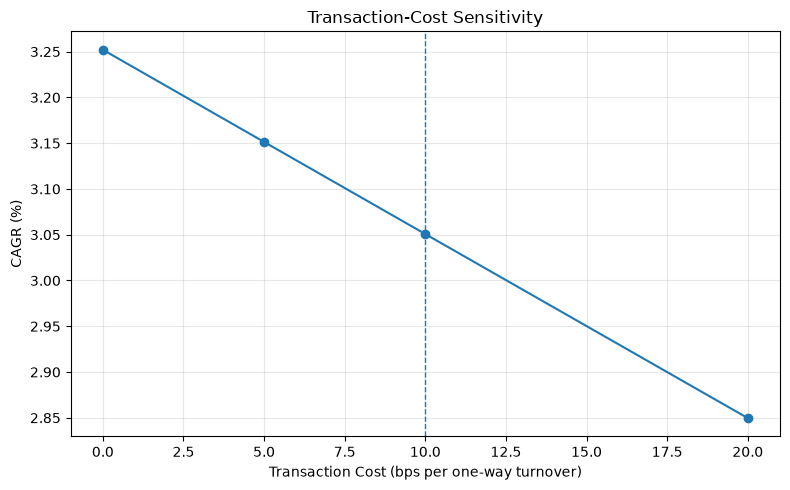

In [12]:
import matplotlib.pyplot as plt

FIGURES_DIR = (
    PROJECT_ROOT
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

cost_plot = (
    cost_sensitivity.copy()
)

cost_plot.index = [
    0,
    5,
    10,
    20,
]

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    cost_plot.index,
    cost_plot["CAGR"] * 100,
    marker="o",
)

ax.axvline(
    10,
    linewidth=1,
    linestyle="--",
)

ax.set_title(
    "Transaction-Cost Sensitivity"
)

ax.set_xlabel(
    "Transaction Cost (bps per one-way turnover)"
)

ax.set_ylabel(
    "CAGR (%)"
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "transaction_cost_sensitivity.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [13]:
figure_files = [
    "cumulative_wealth.png",
    "drawdowns.png",
    "transaction_cost_sensitivity.png",
]

for filename in figure_files:

    file_path = (
        FIGURES_DIR
        / filename
    )

    print(
        filename,
        "->",
        file_path.exists()
    )

cumulative_wealth.png -> True
drawdowns.png -> True
transaction_cost_sensitivity.png -> True
